# LLM-Assisted Cyber Threat Intelligence for 5G O-RAN Security

**Pipeline overview:**
1. Load dataset — NetsLab-5GORAN-IDD (Network_dataset)
2. EDA — class distribution, feature stats, correlation matrix
3. Preprocessing — label-encode categoricals, drop leakage columns, SMOTE-balance minority classes, stratified 80/20 split
4. Train XGBoost (`multi:softprob`) — outputs full class probabilities
5. Evaluate — accuracy, macro F1, confusion matrix, error analysis
6. SHAP — per-prediction TreeExplainer feature importance
7. CTI Alert — ML output → structured JSON alert per O-RAN component
8. LLM Enrichment — Qwen2.5-7B via Ollama contextualises the alert
9. LLM Evaluation — hallucination check, timing, with/without SHAP comparison

---
## Section 0: Setup

Installs required packages and mounts Google Drive for dataset and model access.

In [1]:
# Install dependencies
%pip install xgboost shap matplotlib seaborn scikit-learn pandas numpy ollama imbalanced-learn -q

In [2]:
# Mount Google Drive — put Network_Dataset.csv in Drive under a CTI/ folder
from google.colab import drive
drive.mount('/content/drive')

# ---- update these paths to match where the files live in Drive ----
CSV_PATH        = '/content/drive/MyDrive/CTI/Network_Dataset.csv'
DB_PATH         = '/content/drive/MyDrive/CTI/Network_Dataset.db'  # fallback
MODEL_SAVE_PATH = '/content/drive/MyDrive/CTI/xgb_model.json'
# -------------------------------------------------------------------

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports OK')

All imports OK


In [4]:
# Verify GPU availability
import torch
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU available, using CPU instead.')

!nvidia-smi

Using GPU: Tesla T4
Thu Jul  2 07:27:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

---
## Section 1: Load Data

Loads from CSV (falls back to SQLite if CSV isn't present). The dataset has 1,723,817 rows and 26 columns — pre-processed Zeek flow features from the NetsLab-5GORAN-IDD dataset.

In [5]:
import os

# Prefer CSV — simpler and no sqlite3 needed
# Falls back to SQLite if CSV is missing
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded from CSV: {CSV_PATH}")
else:
    import sqlite3
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM network_data", conn)
    conn.close()
    print(f"Loaded from SQLite: {DB_PATH}")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded from CSV: /content/drive/MyDrive/CTI/Network_Dataset.csv
Shape: (1723817, 26)
Columns: ['uid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'attack_type', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered', 'traffic_type']


,uid,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dst_ip_bytes,ip_proto,http_trans_depth,attack_category,attack_type,files_total_bytes,is_GET_mthd,http_status_error,is_file_transfered,traffic_type
0,CgvPTm2yEMy1O7Jl9k,192.168.0.1,18728,192.168.0.10,80,tcp,-,0.000041,0.0,0.0,...,40,6,0,ddos,tcp_ack,0.0,0,0,0,1
1,CAOgXB1yv9VtvISnDc,172.16.0.3,29039,192.168.0.10,80,tcp,-,0.000746,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1
2,CXyf8S2WNJVYWlDI15,172.31.0.134,7552,192.168.0.10,80,tcp,-,0.000086,0.0,0.0,...,88,6,0,ddos,syn,0.0,0,0,0,1
3,CXjeD72LNi8Cn2EXZ5,172.16.0.4,59569,52.207.202.187,443,tcp,-,594.651675,73426.0,14841.0,...,55360,6,0,ddos,icmp,0.0,0,0,0,1
4,CgGkxuR9gLRepT5j2,172.16.0.3,42502,192.168.0.10,80,tcp,-,0.000290,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1


---
## Section 2: EDA

Exploratory analysis of the NetsLab-5GORAN-IDD dataset — class distribution, feature statistics, and correlation structure.

### 2.1 — Null Check

In [6]:
null_counts = df.isnull().sum()
print('Null counts per column:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No null values — dataset is complete.')

Null counts per column:
No null values — dataset is complete.


### 2.2 — Class Distribution

Class distribution (attack_category):
attack_category
dos           632507
ddos          420282
web           288304
probe         183293
benign        170865
bruteforce     28566
Name: count, dtype: int64

Total samples: 1,723,817


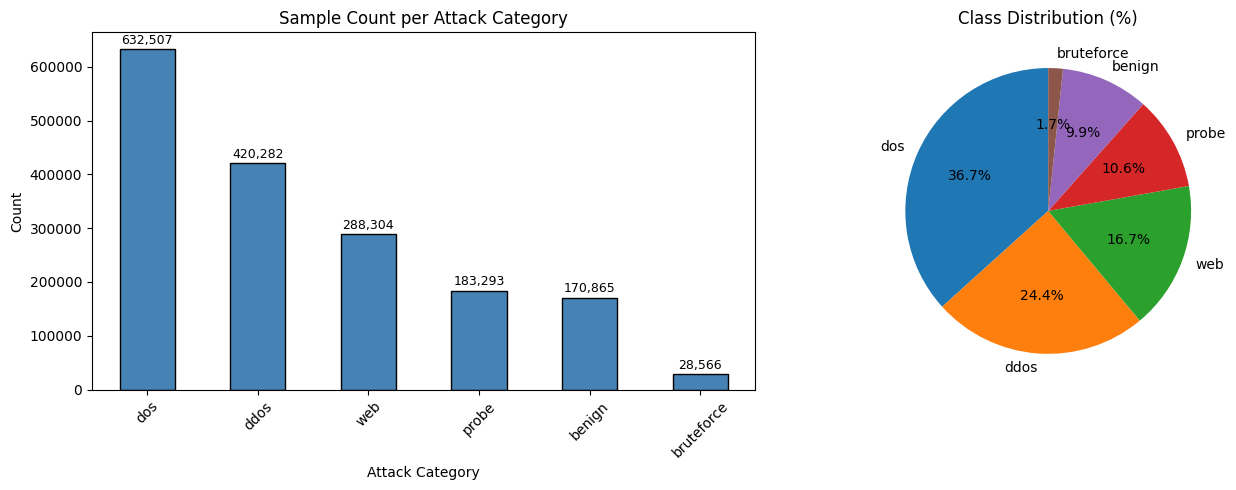

Plot saved.


In [7]:
# attack_category is the ML target (coarse: ddos, dos, probe, etc.)
# attack_type has finer detail (e.g., ddos_syn) — kept out of model features, used in CTI alert only

class_counts = df['attack_category'].value_counts()
print('Class distribution (attack_category):')
print(class_counts)
print(f'\nTotal samples: {len(df):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Count per Attack Category')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 2.3 — Attack Types
*Fine-grained breakdown by category — used in CTI alert generation, not as model features.*

In [8]:
print('Attack types per category:')
print(df.groupby(['attack_category', 'attack_type']).size().to_string())

Attack types per category:
attack_category  attack_type      
benign           benign               170865
bruteforce       ftp                   13664
                 ssh                   14902
ddos             icmp                  11217
                 slowloris             18649
                 syn                  174087
                 tcp_ack              154084
                 udp                   62245
dos              icmp                  13522
                 slowloris             76238
                 syn                  332364
                 tcp_ack               45220
                 udp                  165163
probe            os_fingerprinting     62957
                 portscan_tcp         100000
                 portscan_udp          20336
web              dir_bruteforce        28566
                 http_flood           254314
                 sql_injection          1763
                 xss                    3661


### 2.4 — Categorical Features
*Unique value counts for columns that require label encoding.*

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')
print()
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    if df[col].nunique() <= 20:
        print(f'  Values: {sorted(df[col].unique().tolist())}')

Categorical columns: ['uid', 'src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'history', 'attack_category', 'attack_type']

uid: 1604266 unique values
src_ip: 318 unique values
dst_ip: 1391 unique values
proto: 4 unique values
  Values: ['icmp', 'tcp', 'udp', 'unknown_transport']
service: 15 unique values
  Values: ['-', 'ayiya', 'dhcp', 'dns', 'dtls', 'ftp', 'gtpv1', 'http', 'krb_tcp', 'ldap_udp', 'ntp', 'quic', 'quic,ssl', 'ssh', 'ssl']
conn_state: 13 unique values
  Values: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'RSTRH', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH', 'SHR']
history: 3796 unique values
attack_category: 6 unique values
  Values: ['benign', 'bruteforce', 'ddos', 'dos', 'probe', 'web']
attack_type: 15 unique values
  Values: ['benign', 'dir_bruteforce', 'ftp', 'http_flood', 'icmp', 'os_fingerprinting', 'portscan_tcp', 'portscan_udp', 'slowloris', 'sql_injection', 'ssh', 'syn', 'tcp_ack', 'udp', 'xss']


### 2.5 — Mutual Information Feature Relevance
*Scores each feature by how much it reduces uncertainty about the target class.*
*Identifier and leakage columns are excluded; all others including `history` are scored.*

In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder as _LE

# Exclude identifiers and leakage columns — not modelling candidates
EXCLUDE = ['uid', 'src_ip', 'dst_ip', 'attack_type', 'traffic_type', 'attack_category']
mi_df = df.drop(columns=EXCLUDE).copy()

# Temporarily label-encode all remaining categoricals (including history)
# MI only needs numeric input — the encoding is for scoring only, not modelling
for col in mi_df.select_dtypes(include='object').columns:
    mi_df[col] = _LE().fit_transform(mi_df[col].astype(str))

# Target: exclude bruteforce to match the actual modelling target
_mask = df['attack_category'] != 'bruteforce'
X_mi = mi_df[_mask]
y_mi = _LE().fit_transform(df.loc[_mask, 'attack_category'])

print('Computing mutual information scores (this may take ~30s)...')
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print('\nMutual Information scores (higher = more relevant to target):')
print(mi_series.to_string())

Computing mutual information scores (this may take ~30s)...

Mutual Information scores (higher = more relevant to target):
src_ip_bytes          1.028971
history               0.954656
duration              0.842530
dst_ip_bytes          0.819347
src_port              0.765893
src_bytes             0.737775
conn_state            0.695890
dst_bytes             0.694547
src_pkts              0.616512
files_total_bytes     0.601623
dst_pkts              0.558250
http_trans_depth      0.488200
dst_port              0.478597
is_file_transfered    0.472722
service               0.455446
http_status_error     0.441877
is_GET_mthd           0.394976
proto                 0.102877
ip_proto              0.094088
missed_bytes          0.000374


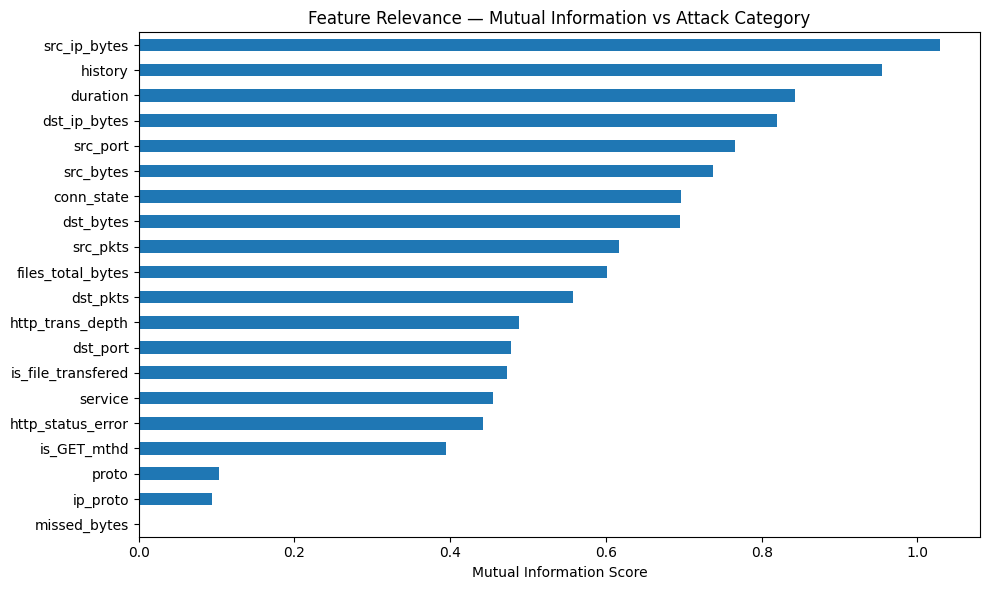

Saved: mi_feature_relevance.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
mi_series.plot(kind='barh', ax=ax, color='#1f77b4')
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Relevance — Mutual Information vs Attack Category')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/mi_feature_relevance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mi_feature_relevance.png')

### 2.6 — Correlation Matrix (Numeric Features)
*Pearson correlation to identify redundant continuous features. Pairs with |r| > 0.95 are candidates for removal.*

*Categorical features (`proto`, `service`, `conn_state`) are excluded — Pearson correlation on label-encoded categoricals is misleading since integer assignments are arbitrary. 

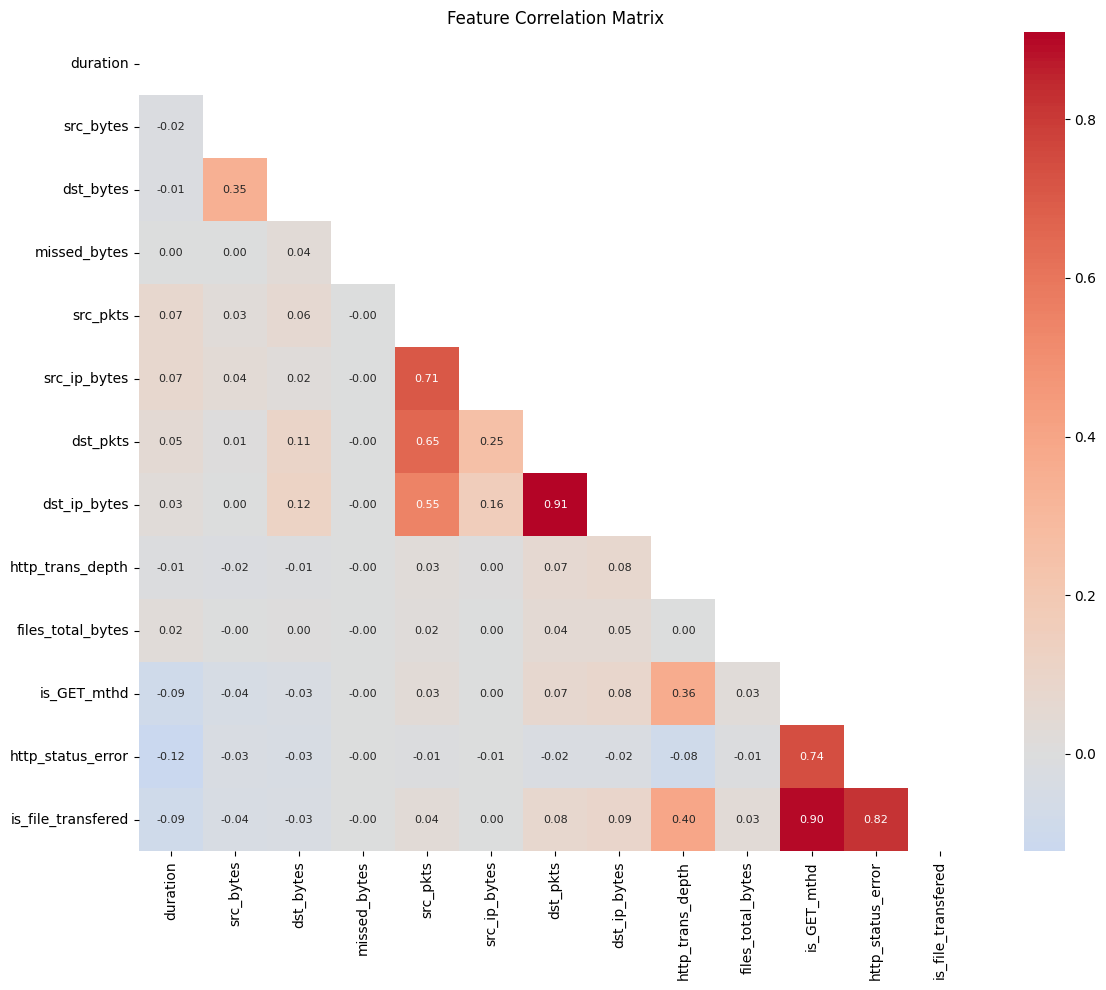

No highly correlated pairs found (|r| > 0.95).


In [15]:
# Numeric columns only.
# ip_proto is stored as int but is semantically categorical (1=ICMP, 6=TCP, 17=UDP).
# traffic_type is a binary label-leakage column — excluded from all feature analysis.
# src_port/dst_port are integer identifiers (ephemeral/service ports), not continuous features.
EXCLUDE_FROM_CORR = ['ip_proto', 'traffic_type', 'src_port', 'dst_port']
numeric_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in EXCLUDE_FROM_CORR]

numeric_df = df[numeric_cols]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (|r| > 0.95)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr:
    print('Highly correlated pairs (|r| > 0.95):')
    for a, b, r in high_corr:
        print(f'  {a} <-> {b}: r={r}')
else:
    print('No highly correlated pairs found (|r| > 0.95).')